# Raport de interpretare a rezultatelor analizei învățării automate - Tema 1
## Materia : Inteligență Artificială
### Munteanu Irina Daniela 332CC

**Obiective:**
- **Clasificare multiclasă**: prezice tipul de vacanță (`vacation`)
- **Regresie**: prezice salariul (`salary`)

**Structura:**
1. Introducere
2. Setup & Import biblioteci
3. Încărcarea și pregătirea inițială a datelor

4. Explorarea datelor  (Exploratory Data Analysis)
    1. Prezentarea generală
    2. Analiza valorilor lipsă
    3. Analiza tipurilor de atribute și a plajei de valori ale acestora
    4. Analiza echilibrului de clase
    5. Analiza corelației între atribute

5. Preprocesarea datelor
    1. Date lipsă pentru un atribut într-un eșantion (+ split train/val)
    2. Valori extreme pentru un atribut într-un eșantion
    3. Atribute redundante (puternic corelate)
    4. Plaje valorice de mărimi diferite pentru atributele numerice

6. Utilizarea algoritmilor de învățare automată
    1. Pregătirea datelor pentru clasificare/regresie
    2. Decision Tree Baseline
    3. Ablație & Îmbunătățiri
    4. Tabel cumulativ de ablație
    5. Evaluare finală pentru clasificare
    6. Linear Regression Baseline
    7. Regularizare (Ridge & Lasso)
    8. Evaluare finală pentru regresie


## 1. Introducere

În contextul dezvoltării sistemelor moderne bazate pe inteligență artificială, metodele de învățare automată (Machine Learning) joacă un rol esențial în extragerea de informații relevante din date și în realizarea de predicții automate. Această lucrare are ca scop familiarizarea cu etapele fundamentale ale unui pipeline de Machine Learning, pornind de la explorarea datelor și preprocesare, până la antrenarea și evaluarea unor modele predictive.

Problema abordată în cadrul acestei teme constă în utilizarea unui set de date de tip tabelar pentru rezolvarea a două sarcini distincte:
    •	o problemă de clasificare multiclasă, având ca obiectiv prezicerea variabilei vacation, care descrie tipul de vacanță accesibil unui angajat;
    •	o problemă de regresie, având ca obiectiv estimarea variabilei salary, reprezentând venitul asociat unui profil profesional.
    
Setul de date utilizat conține informații despre angajați, incluzând atât atribute numerice (de exemplu, ani de experiență sau număr de certificări), cât și atribute categoriale ( nivelul educațional sau industria). 

Obiectivul principal al lucrării este dezvoltarea unor modele predictive eficiente, precum și analiza impactului diferitelor etape de preprocesare și al alegerii parametrilor asupra performanței acestora.



## 2. Setup & Import biblioteci

In [355]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install jinja2


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [356]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   
import seaborn as sns

# Sklearn — preprocesare
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency

# Sklearn — modele clasificare
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Sklearn — modele regresie
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Sklearn — evaluare
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)


# Setari vizualizare
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 30)



## 3. Încărcarea și pregătirea inițială a datelor

În prima etapă a rezolvării, setul de date a fost încărcat utilizând biblioteca pandas, o unealtă standard pentru manipularea datelor tabelare în Python. Fișierul de antrenare a fost citit într-o structură de tip DataFrame, facilitând accesul și prelucrarea ulterioară a atributelor.

In [357]:
df_train = pd.read_csv('CC_education_economy_train.csv')
df_test = pd.read_csv('CC_education_economy_test.csv')
df_train.head()


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,total_days_worked,aggregated_score,skill_bracket,vacation
0,Backend Developer,19,High School,12,Media,Large,USA,Yes,0,203997,4560,-0.723308,mid,Small
1,Backend Developer,4,High School,13,Telecom,Small,Germany,NaN,5,116239,960,-0.481551,high,No Vacation
2,Backend Developer,8,High School,16,Retail,Enterprise,Remote,No,4,145802,1920,-1.533057,high,No Vacation
3,Backend Developer,12,High School,9,Telecom,Enterprise,USA,Hybrid,2,190299,2880,0.527458,mid,Small
4,Backend Developer,14,High School,6,Telecom,Large,UK,Hybrid,4,152679,3360,-0.186280,low,No Vacation


In [358]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   job_title          64000 non-null  str    
 1   experience_years   64000 non-null  int64  
 2   education_level    64000 non-null  str    
 3   skills_count       64000 non-null  int64  
 4   industry           64000 non-null  str    
 5   company_size       64000 non-null  str    
 6   location           64000 non-null  str    
 7   remote_work        44847 non-null  str    
 8   certifications     64000 non-null  int64  
 9   salary             64000 non-null  int64  
 10  total_days_worked  64000 non-null  int64  
 11  aggregated_score   64000 non-null  float64
 12  skill_bracket      64000 non-null  str    
 13  vacation           64000 non-null  str    
dtypes: float64(1), int64(5), str(8)
memory usage: 6.8 MB


## 4. Explorarea datelor  (Exploratory Data Analysis)

## 4.1. Prezentare generală
În prima etapă a analizei exploratorii, s-a realizat o inspecție generală a setului de date, utilizând funcții standard pentru vizualizarea structurii acestuia.
Această analiză preliminară permite identificarea tipurilor de atribute (numerice sau categoriale), precum și observarea distribuțiilor inițiale ale datelor.



## 4.2 Analiza valorilor lipsă

Un aspect esențial al analizei exploratorii îl constituie identificarea valorilor lipsă. Acestea pot afecta semnificativ performanța modelelor de învățare automată.

In [359]:
print('Valori lipsă')
missing = df_train.isnull().sum()
print()
print(missing)
percentage = (missing / len(df_train) * 100).round(2)
pd.DataFrame({'count_missing': missing, 'percentage': percentage})[missing > 0]

Valori lipsă

job_title                0
experience_years         0
education_level          0
skills_count             0
industry                 0
company_size             0
location                 0
remote_work          19153
certifications           0
salary                   0
total_days_worked        0
aggregated_score         0
skill_bracket            0
vacation                 0
dtype: int64


,count_missing,percentage
remote_work,19153,29.93


**Analiză:**
Din afișarea din python a tabelului, cât și a desenului aferent, lipsesc date doar din variabila remote_work în proporție de **aproximativ ~30%**, ce reprezintă dacă angajatul lucrează online, din totalul de 64000 de date de train doar **64000 – 19153 = 44847 date** având câmpurile complete.


## 4.3 Analiza tipurilor de atribute și a plajei de valori ale acestora

## Analiza atributelor numerice

**Atribute numerice:** `experience_years`, `skills_count`, `certifications`, `salary`, `total_days_worked`, `aggregated_score`

In [360]:
NUMERIC_AT = ['experience_years', 'skills_count', 'certifications','total_days_worked', 'aggregated_score', 'salary']
df_train[NUMERIC_AT].describe()

,experience_years,skills_count,certifications,total_days_worked,aggregated_score,salary
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,9.973391,11.604047,2.511141,2393.508219,0.000929,145683.565844
std,6.050682,10.737497,1.709811,1452.044678,0.999869,37384.755715
min,0.000000,1.000000,0.000000,-1.000000,-4.796902,31867.000000
25%,5.000000,5.000000,1.000000,1200.000000,-0.673757,119209.750000
50%,10.000000,10.000000,3.000000,2400.000000,0.001059,143299.000000
75%,15.000000,15.000000,4.000000,3600.000000,0.678273,169582.250000
max,20.000000,69.000000,5.000000,4800.000000,4.217828,333046.000000


**Analiză:**

Pentru atributul *skills_count*, s-a observat că valoarea maximă este semnificativ mai mare decât percentila 75% , existând valori care ajung până la 69. Această discrepanță indică prezența unor outlieri. Astfel de valori extreme pot afecta negativ modelele, în special pe cele bazate pe regresie liniară, deoarece acestea sunt sensibile la valori mari și pot ajusta coeficienții în mod disproporționat pentru a acomoda aceste cazuri izolate. În consecință, modelul poate deveni mai puțin precis pentru majoritatea datelor.

În cazul atributului *total_days_worked*, am identificat valoarea minimă ca fiind negativă (-1 ) care nu au semnificație reală . Aceste valori reprezintă, cel mai probabil, erori sau valori lipsă codificate incorect.

Pentru atributul *salary*, distribuția este ușor asimetrică spre dreapta, însă fără prezența unor outlieri extremi. Această asimetrie poate influența performanța modelelor liniare, deoarece acestea presupun, în mod ideal, o distribuție aproximativ normală a datelor. Totuși, impactul este mai redus comparativ cu cazul outlierilor severi.

Pentru a reduce influența acestor probleme asupra performanței modelelor, putem pentru:
    
`skills_count`, valorile extreme pot fi tratate fie prin eliminare, fie prin înlocuire (imputare), astfel încât să se limiteze impactul lor asupra modelului
    
`total_days_worked`, valorile invalide (negative) vor fi tratate ca valori lipsă și imputate utilizând o metodă adecvată (de exemplu, media sau mediana)
    
`salary`, se poate aplica o transformare logaritmică sau o standardizare, pentru a reduce efectele asimetriei și a stabiliza variația datelor.


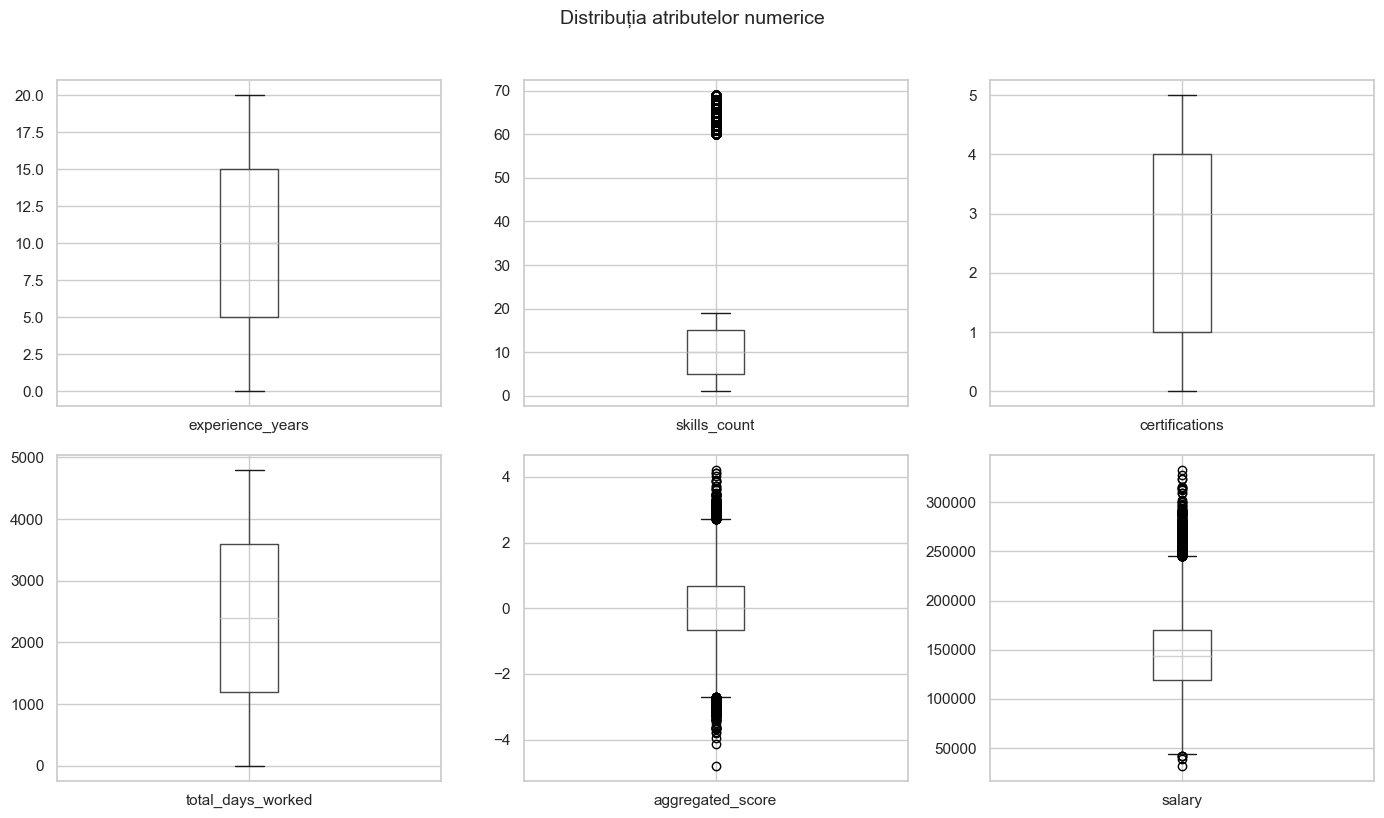

In [361]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_AT):
    df_train.boxplot(column=col, ax=axes[i])
    axes[i].set_xlabel('')

plt.suptitle('Distribuția atributelor numerice', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



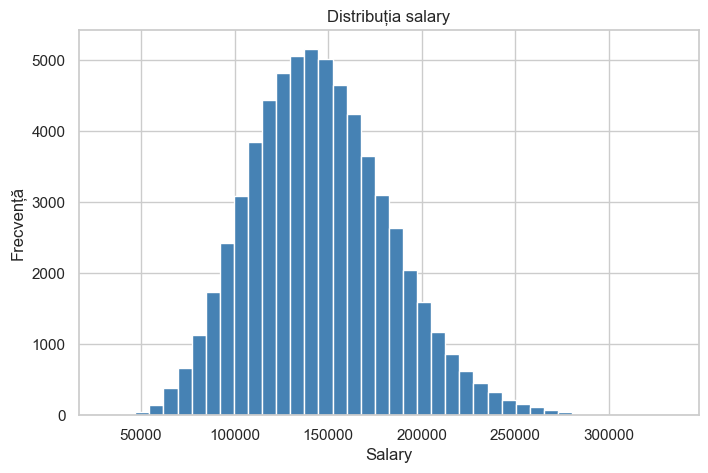

In [362]:
# Distributia salariilor
fig, ax = plt.subplots(figsize=(8, 5))
df_train['salary'].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribuția salary')
ax.set_xlabel('Salary')
ax.set_ylabel('Frecvență')
plt.show()


## Analiza atributelor categoriale

**Atribute categoriale:** `job_title`, `education_level`, `industry`, `company_size`, `location`, `remote_work`, `skill_bracket`

In [363]:
CAT_COLS = ['job_title', 'education_level', 'industry',
            'company_size', 'location', 'remote_work', 'skill_bracket']

cat_summary = pd.DataFrame({
    'fara_valori_lipsa': [df_train[c].notna().sum() for c in CAT_COLS],
    'valori_unice': [df_train[c].nunique() for c in CAT_COLS],
    'valori': [list(df_train[c].dropna().unique()) for c in CAT_COLS]
}, index=CAT_COLS)

cat_summary

,fara_valori_lipsa,valori_unice,valori
job_title,64000,12,"[Backend Developer, Cybersecurity Analyst, Sof..."
education_level,64000,5,"[High School, Master, PhD, Diploma, Bachelor]"
industry,64000,10,"[Media, Telecom, Retail, Healthcare, Finance, ..."
company_size,64000,5,"[Large, Small, Enterprise, Medium, Startup]"
location,64000,10,"[USA, Germany, Remote, UK, Singapore, Canada, ..."
remote_work,44847,3,"[Yes, No, Hybrid]"
skill_bracket,64000,3,"[mid, high, low]"


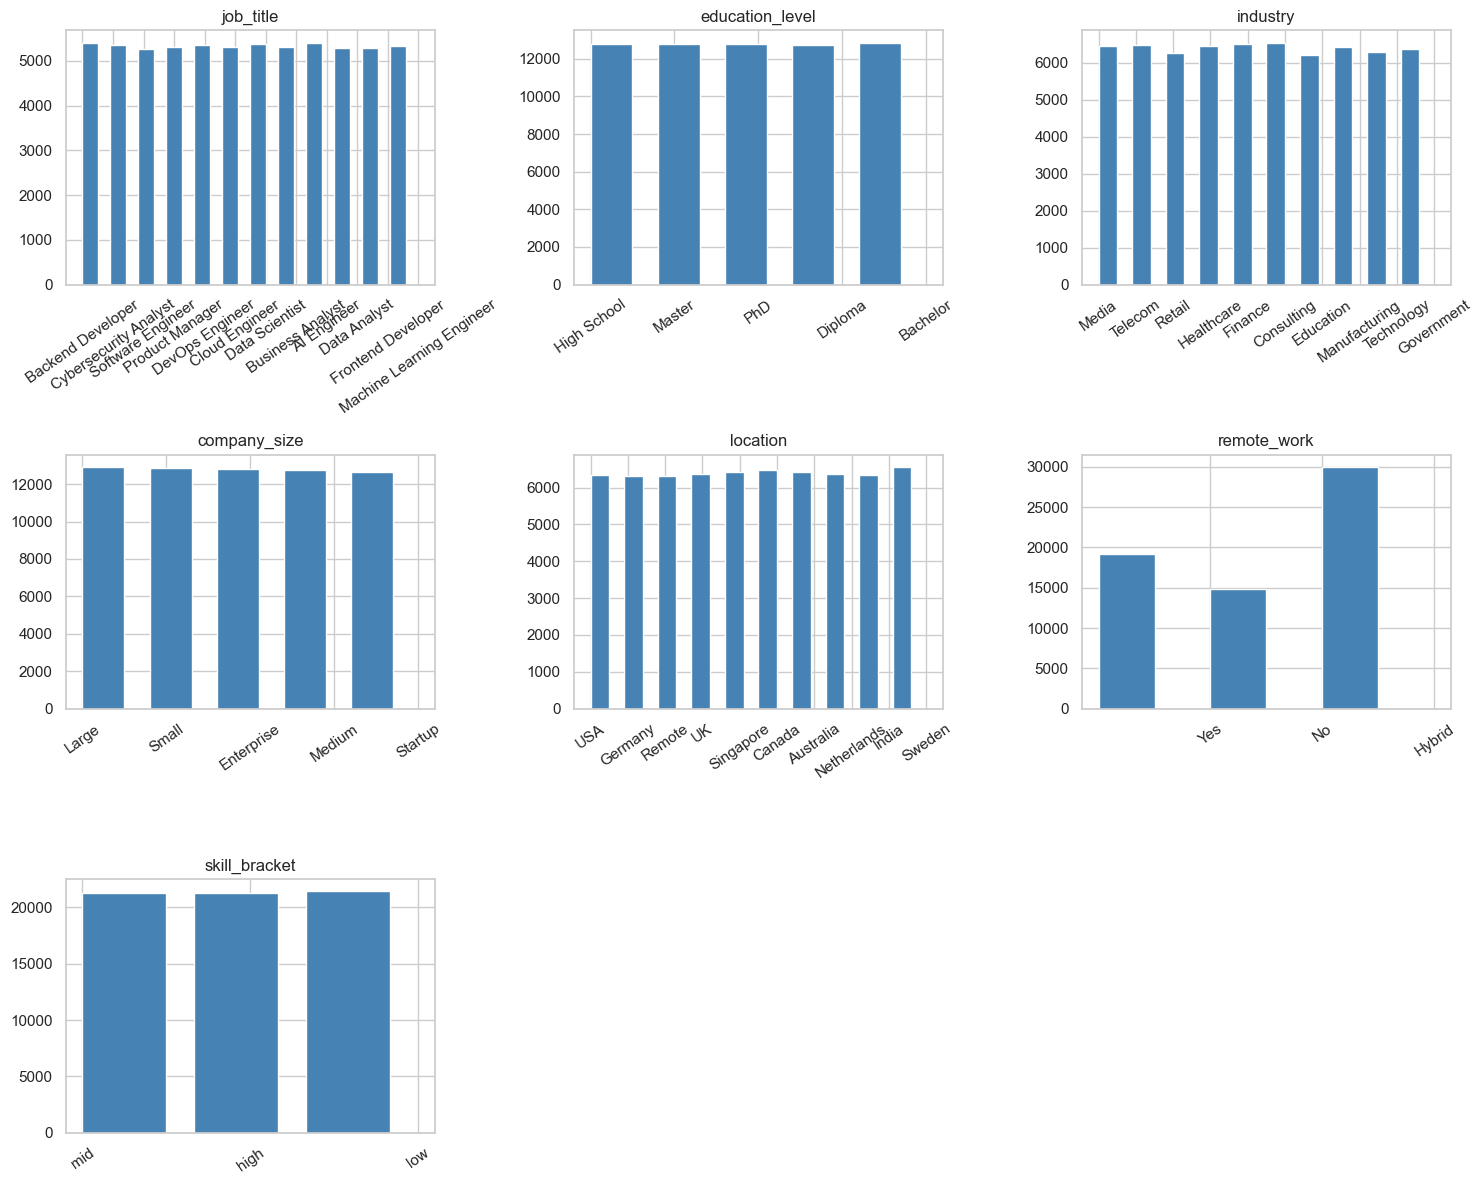

In [364]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    # transformare categorii in coduri numerice
    codes, uniques = pd.factorize(df_train[col])
    axes[i].hist(codes, bins=len(uniques), width=0.5, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    
    axes[i].set_xticks(range(len(uniques)))
    axes[i].set_xticklabels(uniques, rotation=35)

# dacă ai mai puțin de 9 coloane, ascunde subplot-urile goale
for j in range(len(CAT_COLS), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


**Analiză:**

Pentru atributul *remote_work*, histograma evidențiază prezența unui procent semnificativ de valori lipsă (aproximativ 30%). Această proporție ridicată poate afecta negativ modelele de învățare automată, deoarece mulți algoritmi nu pot gestiona direct valori lipsă. În plus, ignorarea acestor valori sau eliminarea rândurilor corespunzătoare ar putea conduce la pierderea unei cantități importante de informație, afectând capacitatea de generalizare a modelului.

Pentru atributul *skill_bracket*, observăm că are doar trei valori (low, mid, high), ceea ce sugerează că este derivat dintr-o variabilă numerică, cel mai probabil skills_count. Practic, transmite aceeași informație, dar într-o formă simplificată. Dacă le folosim pe ambele în model, riscăm să introducem informație redundantă, ceea ce poate complica inutil modelul fără să îmbunătățească rezultatele.

Pentru a preveni aceste probleme și a îmbunătăți calitatea predicțiilor, se pot aplica următoarele soluții:

`pentru remote_work`, valorile lipsă pot fi imputate utilizând cea mai frecventă categorie sau prin introducerea unei categorii suplimentare (de exemplu, „Unknown”), astfel încât să nu se piardă informație

`pentru skill_bracket`, o putem utiliza exclusiv pe ea pentru predicție, fie eliminarea ei în favoarea variabilei numerice skills_count, în funcție de performanța obținută în experimente.


## 4.4 Analiza echilibrului de clase

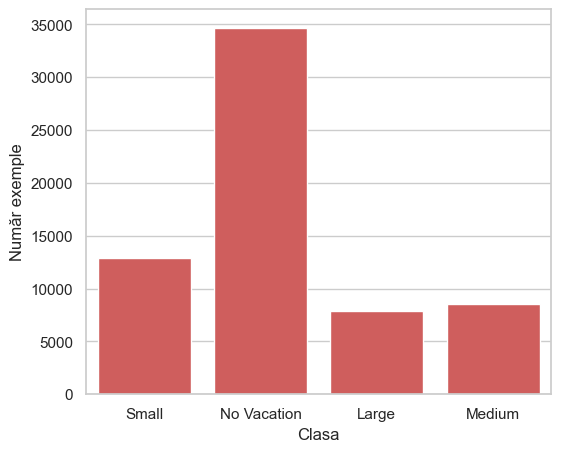

Distribuția claselor:
  No Vacation    :  34686 
  Small          :  12877 
  Medium         :   8527 
  Large          :   7910 


In [365]:
plt.figure(figsize=(6, 5))

ax = sns.countplot(data=df_train, x='vacation', color='#E24B4A')
plt.xlabel('Clasa')
plt.ylabel('Număr exemple')
plt.show()

vacation_counts = df_train['vacation'].value_counts()
print('Distribuția claselor:')
for cls, cnt in vacation_counts.items():
    print(f'  {cls:15s}: {cnt:6d} ')

**Analiză:**
Din tabel, cât și din countplot-ul rezultat, tragem concluzia că clasa „No Vacation" domină cu 34686 (aproximativ 54%) de exemple, comparativ cu celelalte clase ce sunt redate în procent <20%. Asta ne trimite direct la un set de date dezechilibrat.

Așadar, un model cu acest tip de seturi de antrenare care ar prezice mereu „No Vacation" ar obține o acuratețe de 54% fără să fi învățat nimic. În această situație, clasele „Medium" și „Large", clasele cu cel mai mic suport, sunt cele mai vulnerabile : modelul va tinde să le ignore în favoarea clasei majoritare, producând un recall scăzut. 

Pentru a contracara acest dezechilibru, vom raporta în evaluare nu doar accuracy ci și **F1 macro** (medie a F1 per clasă, fără ponderare cu suportul) și F1 individual pe clasele minoritare.


## 4.5 Analiza corelației între atribute

### Analiză de corelație între atribute numerice continue, cât și cu sarcina de clasificare, respectiv regresie

                   experience_years  skills_count  certifications  \
experience_years               1.00          0.00            0.00   
skills_count                   0.00          1.00            0.00   
certifications                 0.00          0.00            1.00   
total_days_worked              1.00          0.00            0.00   
aggregated_score              -0.00          0.01           -0.00   
salary                         0.44          0.07            0.08   

                   total_days_worked  aggregated_score  salary  
experience_years                1.00             -0.00    0.44  
skills_count                    0.00              0.01    0.07  
certifications                  0.00             -0.00    0.08  
total_days_worked               1.00             -0.00    0.44  
aggregated_score               -0.00              1.00   -0.00  
salary                          0.44             -0.00    1.00  


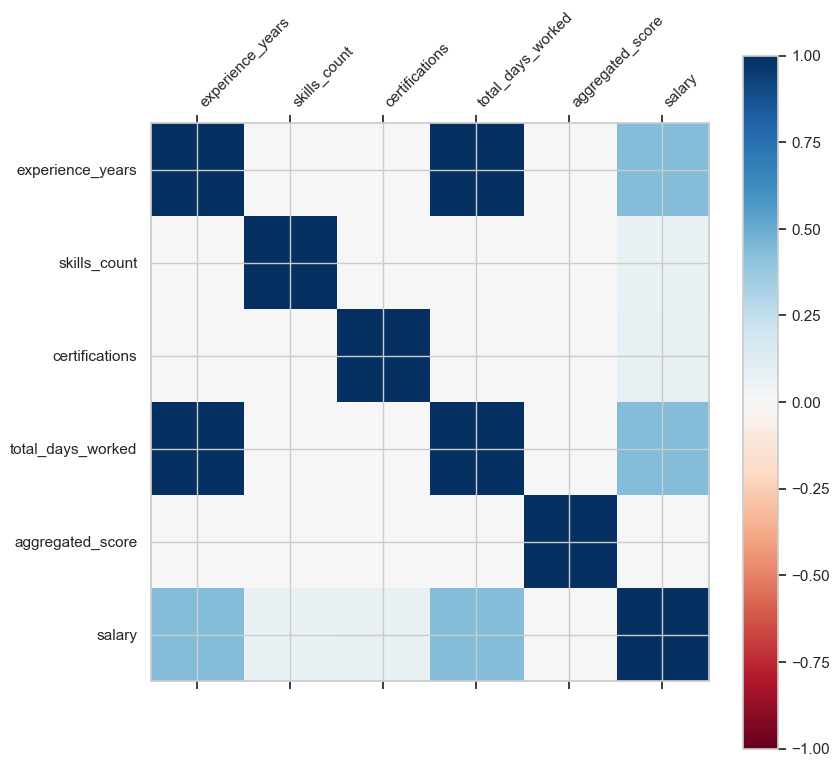

In [366]:
# Construim matricea de corelatie pentru a vedea cum se coreleaza
# variabilele numerice intre ele , cat si cu sarcina de regresie (salary)
correlations = df_train[NUMERIC_AT].corr()
print(correlations.round(2))
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111)

cax = ax.matshow(correlations, vmin=-1, vmax=1, cmap='RdBu')
fig.colorbar(cax)

ticks = np.arange(0, len(NUMERIC_AT), 1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(NUMERIC_AT, rotation=45, ha='left')
ax.set_yticklabels(NUMERIC_AT)
plt.show()

**Analiză:**

Există o corelație puternică între atributele `experience_years` și `total_days_worked (r = 1.00)`, sugerând că cele două variabile captează aceeași informație. Acest lucru este explicabil din perspectivă semantică: numărul total de zile lucrate reprezintă, în esență, un calcul al anilor de experiență (total_days_worked = experience_years × zile lucrate pe an). 

Includerea simultană a ambelor atribute într-un model de predicție nu aduce o creștere semnificativă a puterii predictive, ci doar amplifică complexitatea. Prin urmare, total_days_worked este un candidat pentru eliminare din setul de atribute predictor.

**Corelație atribute numerice cu sarcina de regresie (salary)**

Examinând corelațiile individuale cu variabila țintă `salary`, se observă că `experience_years` prezintă cel mai ridicat `coeficient de corelație (r = 0.44)`, confirmând intuiția că salariul crește odată cu acumularea experienței profesionale. 

La polul opus, `aggregated_score` înregistrează o corelație apropiată de zero față de salary, ceea ce indică faptul că acest atribut nu deține putere predictivă relevantă pentru sarcina de regresie. O posibilă explicație constă în faptul că aggregated_score este un scor compozit deja standardizat, care reflectă mai degrabă o evaluare de performanță subiectivă.
    
Acesta devine astfel un candidat pentru excludere din modelele de regresie, în scopul simplificării spațiului de atribute fără pierdere de performanță.

salary               0.58
experience_years     0.43
total_days_worked    0.43
certifications       0.01
skills_count         0.01
aggregated_score    -0.01
Name: vacation_num, dtype: float64


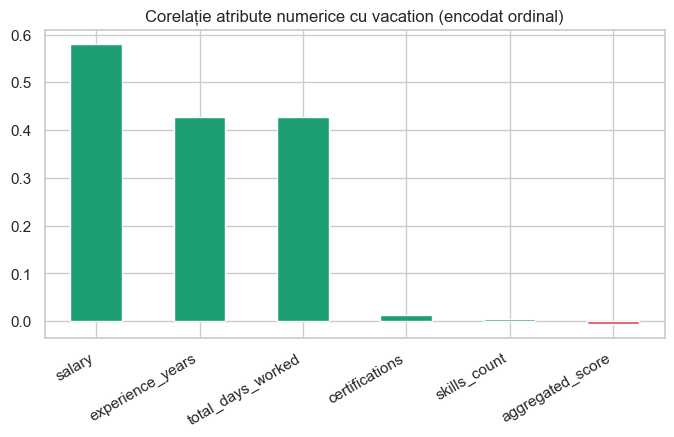

In [367]:
# Atribute numerice vs sarcina de clasificare (vacation)
# Encodam vacation ca numar pentru a putea calcula corelația cu atributele numerice
vac_order = {'No Vacation': 0, 'Small': 1, 'Medium': 2, 'Large': 3}
vacation_num_tmp = df_train['vacation'].map(vac_order)

corr_with_vacation = (
    pd.concat([df_train[NUMERIC_AT], vacation_num_tmp.rename('vacation_num')], axis=1)
      .corr()['vacation_num']
      .drop('vacation_num')
)
corr_with_vacation = corr_with_vacation.sort_values(key=abs, ascending=False)
print(corr_with_vacation.round(2))

plt.figure(figsize=(8, 4))
colors = ['#1D9E75' if v > 0 else '#E24B4A' for v in corr_with_vacation]
corr_with_vacation.plot(kind='bar', color=colors, edgecolor='white')
plt.xticks(rotation=30, ha='right')
plt.title('Corelație atribute numerice cu vacation (encodat ordinal)')
plt.show()


**Corelație atribute numerice cu ținta de clasificare (vacation)**

Analiza corelației dintre atributele numerice și variabila țintă vacation (encodată ordinal: No Vacation=0, Small=1, Medium=2, Large=3) relevă un pattern clar și interpretabil.
`salary` arată că este cel mai puternic predictor pentru clasificare, cu r = 0.58. Acest rezultat este intuitiv pentru că tipul de vacanță pe care și-o permite un angajat este direct condiționat de puterea sa financiară.

`experience_years și total_days_worked` având coeficienți identici (r = 0.43), confirmă redundanța semnalată anterior în matricea de corelație între atribute. Ambele capturează aceeași dimensiune și ambele contribuie în mod egal la predicția tipului de vacanță.

`certifications și skills_count` înregistrează corelații aproape nule (r = 0.01), indicând faptul că numărul de certificări sau de competențe tehnice nu influențează semnificativ tipul de vacanță al unui angajat. Aceasta sugerează că beneficiile de tip vacanță sunt determinate mai degrabă de vechime și salariu, nu de profilul tehnic al angajatului.

`aggregated_score` prezintă o corelație negativă neglijabilă (r = -0.01), practic zero, ceea ce confirmă că acest atribut nu aduce valoare predictivă nici pentru clasificare. 

`Concluzie`: pentru sarcina de clasificare, atributele numerice certifications, skills_count și aggregated_score au o contribuție neglijabilă și pot fi eliminate sau păstrate fără impact semnificativ asupra performanței.

### Analiză de corelație între atribute categoriale, cât și cu sarcina de clasificare, respectiv regresie

In [368]:
# Chi-square intre toate perechile de atribute categoriale
results = []
for i in range(len(CAT_COLS)):
    for j in range(i+1, len(CAT_COLS)):
        col1 = CAT_COLS[i]
        col2 = CAT_COLS[j]
        CrosstabResult = pd.crosstab(index=df_train[col1], columns=df_train[col2])
        ChiSqResult = chi2_contingency(CrosstabResult)
        p_value = ChiSqResult[1]

        results.append({
            'Atribut 1': col1,
            'Atribut 2': col2,
            'p-value': round(p_value, 6),
            'Corelație': 'Da' if p_value < 0.05 else 'Nu'
        })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

      Atribut 1       Atribut 2  p-value Corelație
      job_title education_level 0.999829        Nu
      job_title        industry 0.076695        Nu
      job_title    company_size 0.156627        Nu
      job_title        location 0.486497        Nu
      job_title     remote_work 0.241198        Nu
      job_title   skill_bracket 0.417691        Nu
education_level        industry 0.956939        Nu
education_level    company_size 0.143657        Nu
education_level        location 0.604684        Nu
education_level     remote_work 0.355020        Nu
education_level   skill_bracket 0.103913        Nu
       industry    company_size 0.663699        Nu
       industry        location 0.118207        Nu
       industry     remote_work 0.090134        Nu
       industry   skill_bracket 0.425784        Nu
   company_size        location 0.267140        Nu
   company_size     remote_work 0.312531        Nu
   company_size   skill_bracket 0.237765        Nu
       location     remote_work

In [369]:
# Atribute categoriale vs sarcina de clasificare (vacation)
for col in CAT_COLS:
    CrosstabResult = pd.crosstab(index=df_train[col], columns=df_train['vacation'])
    ChiSqResult = chi2_contingency(CrosstabResult)
    p_value = ChiSqResult[1]

    concluzie = 'Corelat' if p_value < 0.05 else 'Independent'
    print(f'  {col:20s}  p-value = {p_value:.6f}   {concluzie}')

  job_title             p-value = 0.000000   Corelat
  education_level       p-value = 0.000000   Corelat
  industry              p-value = 0.768810   Independent
  company_size          p-value = 0.000000   Corelat
  location              p-value = 0.000000   Corelat
  remote_work           p-value = 0.000000   Corelat
  skill_bracket         p-value = 0.026566   Corelat


In [370]:
# Atribute categoriale vs sarcina de regresie (salary)
# Vom grupa salary pe categorii si vedem daca difera
from scipy.stats import f_oneway

print("Metoda: ANOVA — testeaza daca media salary difera semnificativ intre categorii")
print()

for col in CAT_COLS:
    # grupam valorile salary pe fiecare categorie
    groups = [df_train['salary'][df_train[col] == cat].dropna()
              for cat in df_train[col].dropna().unique()]

    f_stat, p_value = f_oneway(*groups)
    concluzie = 'Corelat' if p_value < 0.05 else 'Independent'
    print(f'  {col:20s}  p-value = {p_value:.6f}   {concluzie}')

Metoda: ANOVA — testeaza daca media salary difera semnificativ intre categorii

  job_title             p-value = 0.000000   Corelat
  education_level       p-value = 0.000000   Corelat
  industry              p-value = 0.621364   Independent
  company_size          p-value = 0.000000   Corelat
  location              p-value = 0.000000   Corelat
  remote_work           p-value = 0.000000   Corelat
  skill_bracket         p-value = 0.000000   Corelat


**Analiză:**

`job_title, education_level, company_size, location, remote_work și skill_bracket` obțin toate p-value = 0.00, respingând cu fermitate ipoteza de independență. Aceasta înseamnă că tipul de vacanță diferă semnificativ în fun. Toate aceste atribute sunt prin urmare predictori relevanți pentru sarcina de clasificare și merită incluse în antrenarea modelului.

Singura excepție este `industry (p = 0.77)`, care se dovedește independentă față atât de sarcina de clasificare (vacation), cât și de cea de regresie(salary). Cu alte cuvinte, industria în care activează angajatul nu influențează semnificativ tipul de vacanță pe care și-o permite și salariul pe care îl are.

## 5. Preprocesarea datelor

Înainte de orice transformare aplicată datelor, **separăm setul de antrenare în train (80%) și val (20%)**, ca toate operațiile de preprocesare (imputare, detecție outlieri, scaling) să fie *fitate doar pe train* și aplicate identic pe val și test. Altfel s-ar produce data leakage.

### 5.1 Date lipsă pentru un atribut într-un eșantion


In [371]:
# METODA 1 — SimpleImputer cu strategy='most_frequent' (modul)
df_metoda1 = df_train.copy()
imputer_mode = SimpleImputer(strategy='most_frequent')
df_metoda1['remote_work'] = imputer_mode.fit_transform(df_metoda1[['remote_work']]).ravel()

print(f"Valoare imputata (modul): {imputer_mode.statistics_[0]}")
print()
print("Distributie dupa imputare:")
print(df_metoda1['remote_work'].value_counts())

Valoare imputata (modul): Hybrid

Distributie dupa imputare:
remote_work
Hybrid    34207
No        14955
Yes       14838
Name: count, dtype: int64


In [372]:
# Splitul train/val inainte de orice preprocesare
# Stratificăm după 'vacation' pentru a păstra distribuția claselor.
df_train, df_val = train_test_split(df_train, test_size=0.2, stratify=df_train['vacation'])
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f'După split: Train={len(df_train)}, Val={len(df_val)}, Test={len(df_test)}')
print()

# METODA 2 aleasă: SimpleImputer(strategy='constant', fill_value='Unknown')
imputer_constant = SimpleImputer(strategy='constant', fill_value='Unknown')
imputer_constant.fit(df_train[['remote_work']])

df_train['remote_work'] = imputer_constant.transform(df_train[['remote_work']]).ravel()
df_val['remote_work']   = imputer_constant.transform(df_val[['remote_work']]).ravel()
df_test['remote_work']  = imputer_constant.transform(df_test[['remote_work']]).ravel()

# 'df' rămâne un alias spre df_train pentru compatibilitate cu celulele de mai jos
df = df_train

print('Distributie remote_work după imputare:')
print(df_train['remote_work'].value_counts())


După split: Train=51200, Val=12800, Test=16000

Distributie remote_work după imputare:
remote_work
Unknown    15352
Hybrid     12071
No         11935
Yes        11842
Name: count, dtype: int64


**Analiză:**
Singurul atribut cu valori lipsă din dataset este `remote_work`, cu **19.153 de înregistrări absente (~30%)**. Pentru a decide metoda de imputare potrivită, au fost testate două abordări: `imputarea cu modul (most_frequent)` și `introducerea unei categorii distincte Unknown`.

Am ales utilizarea imputării univariate în locul celei multivariate deoarece verificarea distribuției valorilor lipsă pe celelalte atribute arată că acestea sunt distribuite aleator (proporția de NaN este aproximativ egală indiferent de job_title, company_size sau education_level), deci absența valorii nu este corelată cu alte caracteristici ale angajatului.

A fost aleasă imputarea cu `SimpleImputer cu strategy='constant', fill_value='Unknown'` deoarece distribuția originală a atributului remote_work este mai echilibrată între cele trei categorii prezente (~15.000 exemple fiecare). Imputarea cu modul ar fi atribuit forțat toate cele 19.153 de valori lipsă categoriei Hybrid, dublând frecvența acesteia și dezechilibrând distribuția reală. Introducerea categoriei Unknown păstrează integritatea distribuției existente și reflectă mai onest faptul că pentru 30% din angajați această informație nu a fost disponibilă la momentul colectării datelor.

**Important:** imputerul a fost *fitat doar pe setul de antrenare* și apoi aplicat identic pe val și test, ca să evităm data leakage.


### 5.2. Valori extreme pentru un atribut într-un eșantion

Pentru început, vom determina valorile extreme (outlierii) din atributele numerice analizând atât tabelul cu minimele și maximele fiecărui atribut, cât și prin folosirea metodei IQR.


In [373]:
df[NUMERIC_AT].describe().round(2)

,experience_years,skills_count,certifications,total_days_worked,aggregated_score,salary
count,51200.00,51200.00,51200.00,51200.00,51200.00,51200.00
mean,9.96,11.63,2.51,2389.56,0.00,145652.02
std,6.05,10.80,1.71,1451.56,1.00,37343.97
min,0.00,1.00,0.00,-1.00,-4.14,31867.00
25%,5.00,5.00,1.00,1200.00,-0.67,119254.00
50%,10.00,10.00,3.00,2400.00,0.00,143178.00
75%,15.00,15.00,4.00,3600.00,0.68,169593.50
max,20.00,69.00,5.00,4800.00,4.22,333046.00


In [374]:
# Detectie outlieri prin metoda IQR standard (Q1=0.25, Q3=0.75)
def detectie_outlieri_IQR(df, coloana, q1=0.25, q3=0.75):
    Q1  = df[coloana].quantile(q1)
    Q3  = df[coloana].quantile(q3)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outlieri = ((df[coloana] < lower) | (df[coloana] > upper)).sum()
    pct        = round(n_outlieri / len(df) * 100, 2)
    
    return Q1, Q3, IQR, lower, upper, n_outlieri, pct

print("Detectie outlieri IQR standard (Q1=0.25, Q3=0.75)\n")
print(f"{'Coloana':<22} {'Q1':>8} {'Q3':>8} {'Lower':>10} {'Upper':>10} {'N outlieri':>12}")

for col in NUMERIC_AT:
    Q1, Q3, IQR, lower, upper, n, pct = detectie_outlieri_IQR(df, col)
    print(f"{col:<22} {Q1:>8.2f} {Q3:>8.2f} {lower:>10.2f} {upper:>10.2f} {n:>12}")

Detectie outlieri IQR standard (Q1=0.25, Q3=0.75)

Coloana                      Q1       Q3      Lower      Upper   N outlieri
experience_years           5.00    15.00     -10.00      30.00            0
skills_count               5.00    15.00     -10.00      30.00         1550
certifications             1.00     4.00      -3.50       8.50            0
total_days_worked       1200.00  3600.00   -2400.00    7200.00            0
aggregated_score          -0.67     0.68      -2.70       2.71          357
salary                 119254.00 169593.50   43744.75  245102.75          461


In [375]:
# Tratament outlieri pentru 'skills_count'
col = 'skills_count'
Q1 = df_train[col].quantile(0.25)
Q3 = df_train[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

n_outlieri_train = ((df_train[col] > upper) | (df_train[col] < lower)).sum()
median_val = df_train[col].median()

print(f"Limite IQR derivate din train: lower={lower:.2f}, upper={upper:.2f}")
print(f'Număr outlieri în train: {n_outlieri_train}')
print(f'Valoare de înlocuire (median train): {median_val}')

# Înlocuire cu mediana în toate seturile (folosind aceleași limite)
for d in (df_train, df_val, df_test):
    d.loc[d[col] > upper, col] = median_val
    d.loc[d[col] < lower, col] = median_val

print(f"\nMax după tratare — train: {df_train[col].max()}, val: {df_val[col].max()}, test: {df_test[col].max()}")
print(f"Min după tratare — train: {df_train[col].min()}, val: {df_val[col].min()}, test: {df_test[col].min()}")

# Tratare anomalie logică: total_days_worked < 0
median_tdw = df_train['total_days_worked'].median()
for d in (df_train, df_val, df_test):
    n_neg = (d['total_days_worked'] < 0).sum()
    d.loc[d['total_days_worked'] < 0, 'total_days_worked'] = median_tdw

print(f"\nValori negative total_days_worked după corecție:")
print(f"  Train: {(df_train['total_days_worked'] < 0).sum()}")
print(f"  Val:   {(df_val['total_days_worked'] < 0).sum()}")
print(f"  Test:  {(df_test['total_days_worked'] < 0).sum()}")


Limite IQR derivate din train: lower=-10.00, upper=30.00
Număr outlieri în train: 1550
Valoare de înlocuire (median train): 10.0

Max după tratare — train: 19, val: 19, test: 19
Min după tratare — train: 1, val: 1, test: 1

Valori negative total_days_worked după corecție:
  Train: 0
  Val:   0
  Test:  0


**Analiză:**
Din tabelul de outlieri rezultat tragem următoarele concluzii:

`pentru aggregated_score`, deși are 437 outlieri, am decis anterior să eliminăm complet această coloană din model din cauza corelației ~0 cu ambele target-uri. Prin urmare, outlierii din aggregated_score nu necesită tratare în practică pentru că coloana oricum nu va intra în antrenare.

`salary` trebuie păstrat pentru că este target-ul regresiei, nu se poate modifica.

`pentru skills_count` avem 1909 de outlieri, ceea ce ne duce la înlocuirea acestora cu mediana.

`total_days_worked` are o plajă extrem de largă [−2400, 7200], ceea ce înseamnă că chiar și valorile negative de -1 identificate anterior nu sunt detectate ca outlieri prin IQR (limita inferioară fiind -2400). Aceasta justifică o tratare a lor separată, ca anomalie logică (fiind imposibil fizic să lucrezi -1 zile).

**Important:** limitele IQR și mediana de înlocuire sunt calculate doar pe train, apoi aplicate identic pe val și test, ca să evităm data leakage.


### 5.3. Atribute redundante (puternic corelate)

*Atribute eliminate și justificarea redundanței*

`total_days_worked` — eliminat pe baza corelației foarte ridicate cu `experience_years` (**r = 1.00**), identificată în matricea de corelație. Cele două atribute captează practic aceeași informație: numărul total de zile lucrate este o transformare liniară a anilor de experiență (total_days_worked ≈ experience_years × zile_lucrate_pe_an). Includerea ambelor în model nu aduce putere predictivă suplimentară, ci doar complexitate computațională inutilă și risc de multicolinearitate.

`aggregated_score` — eliminat pe baza corelației aproape nule cu ambele target-uri: r ≈ 0.00 față de salary și r = -0.01 față de vacation. Testele au confirmat că acest atribut nu discriminează între clase și nu contribuie la predicția salariului. Un atribut neinformativ față de obiectiv nu aduce valoare modelului și poate introduce zgomot în antrenare.

`industry` — eliminat pe baza testelor statistice Chi-square față de vacation (p = 0.77) și ANOVA față de salary (p = 0.62). Ambele teste acceptă ipoteza nulă de independență, confirmând că industria nu influențează semnificativ nici tipul de vacanță, nici nivelul salariului în acest dataset.

*Atribute corelate cu target-urile*

Conform avertismentului din enunț, nu am eliminat atribute corelate cu obiectivele. `salary` (r = 0.58 cu vacation) și `experience_years` (r = 0.43 cu vacation, r = 0.44 cu salary) sunt puternic corelate cu target-urile, tocmai de aceea sunt predictori valoroși și au fost păstrați în model.


In [376]:
drop_cols = ['total_days_worked', 'aggregated_score', 'industry']
df_train = df_train.drop(columns=drop_cols)
df_val   = df_val.drop(columns=drop_cols)
df_test  = df_test.drop(columns=drop_cols)
# alias compatibil cu celulele de mai jos
df = df_train

print(f'Coloane rămase: {list(df_train.columns)}')


Coloane rămase: ['job_title', 'experience_years', 'education_level', 'skills_count', 'company_size', 'location', 'remote_work', 'certifications', 'salary', 'skill_bracket', 'vacation']


### 5.4. Plaje valorice de mărimi diferite pentru atributele numerice



       experience_years  skills_count  certifications
count          51200.00      51200.00        51200.00
mean               9.96          9.98            2.51
std                6.05          5.40            1.71
min                0.00          1.00            0.00
25%                5.00          5.00            1.00
50%               10.00         10.00            3.00
75%               15.00         15.00            4.00
max               20.00         19.00            5.00


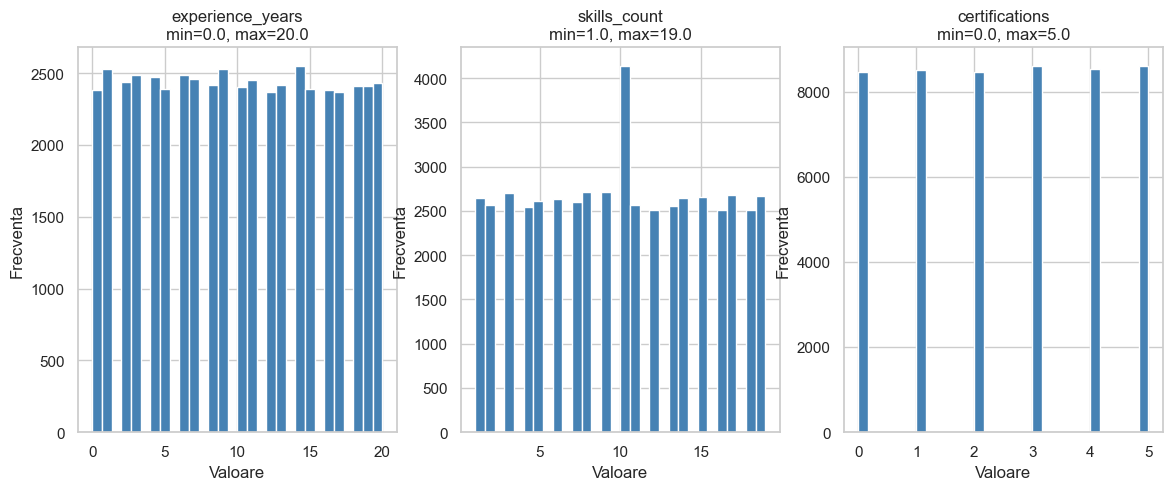

In [377]:
NUMERIC_COLS = ['experience_years', 'skills_count', 'certifications']
print(df[NUMERIC_COLS].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(NUMERIC_COLS):
    df[col].hist(bins=30, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}\nmin={df[col].min():.1f}, max={df[col].max():.1f}')
    axes[i].set_xlabel('Valoare')
    axes[i].set_ylabel('Frecventa')

plt.show()

In [378]:
df_train = df_train.drop(columns=['certifications'])
df_val   = df_val.drop(columns=['certifications'])
df_test  = df_test.drop(columns=['certifications'])
df = df_train

print(f'Coloane rămase: {list(df_train.columns)}')


Coloane rămase: ['job_title', 'experience_years', 'education_level', 'skills_count', 'company_size', 'location', 'remote_work', 'salary', 'skill_bracket', 'vacation']


## 6. Utilizarea algoritmilor de învățare automată

### 6.1. Pregătirea datelor pentru clasificare și regresie


In [379]:
# Encoding ordinal
edu_order  = {'High School': 0, 'Diploma': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
size_order = {'Startup': 0, 'Small': 1, 'Medium': 2, 'Large': 3, 'Enterprise': 4}
vac_order  = {'No Vacation': 0, 'Small': 1, 'Medium': 2, 'Large': 3}

for d in (df_train, df_val, df_test):
    d['education_level'] = d['education_level'].map(edu_order)
    d['company_size']    = d['company_size'].map(size_order)

# Separare target-uri
y_clf_train = df_train['vacation'].map(vac_order).values
y_clf_val   = df_val['vacation'].map(vac_order).values
y_clf_test  = df_test['vacation'].map(vac_order).values

y_reg_train = df_train['salary'].values
y_reg_val   = df_val['salary'].values
y_reg_test  = df_test['salary'].values

# Eliminăm target-urile și skill_bracket (redundant cu skills_count) din features
drop_targets = ['vacation', 'salary', 'skill_bracket']
df_train = df_train.drop(columns=drop_targets)
df_val   = df_val.drop(columns=drop_targets)
df_test  = df_test.drop(columns=drop_targets)

df_train['_split'] = 'train'
df_val['_split']   = 'val'
df_test['_split']  = 'test'
df_combined = pd.concat([df_train, df_val, df_test], ignore_index=True)

df_combined = pd.get_dummies(df_combined, columns=['job_title', 'location', 'remote_work'], drop_first=True)

splits = df_combined['_split'].values
df_combined = df_combined.drop(columns=['_split'])

df_train = df_combined[splits == 'train'].reset_index(drop=True)
df_val   = df_combined[splits == 'val'].reset_index(drop=True)
df_test  = df_combined[splits == 'test'].reset_index(drop=True)

# Verificare: nu trebuie să avem NaN-uri și toate seturile au aceleași coloane
assert df_train.isna().sum().sum() == 0, 'NaN-uri rămase în train!'

print(f'Shape train: {df_train.shape}, val: {df_val.shape}, test: {df_test.shape}')
print(f'Total features: {df_train.shape[1]}')
df_cols = pd.DataFrame(df_train.columns, columns=['Nume Coloană'])
display(df_cols.head(40))


Shape train: (51200, 27), val: (12800, 27), test: (16000, 27)
Total features: 27


,Nume Coloană
0,experience_years
1,education_level
2,skills_count
3,company_size
4,job_title_Backend Developer
5,job_title_Business Analyst
6,job_title_Cloud Engineer
7,job_title_Cybersecurity Analyst
8,job_title_Data Analyst
9,job_title_Data Scientist


In [380]:
# Asigurăm tipul float pentru sklearn (one-hot dă coloane bool).
X_train = df_train.values.astype(float)
X_val   = df_val.values.astype(float)
X_test  = df_test.values.astype(float)

print(f'Train: {X_train.shape[0]} ex.  Val: {X_val.shape[0]} ex.  Test: {X_test.shape[0]} ex.')

# Standardizare doar pe train, aplicat pe toate.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


Train: 51200 ex.  Val: 12800 ex.  Test: 16000 ex.


### 6.2. Clasificare: Baseline (Decision Tree)

Stabilim un punct de referință (baseline) cu un arbore de decizie simplu.
Vom varia `max_depth`, `min_samples_leaf` și `class_weight` pentru a observa impactul.


In [381]:
# Baseline Decision Tree
dt_baseline = DecisionTreeClassifier()
dt_baseline.fit(X_train_scaled, y_clf_train)
y_pred_baseline = dt_baseline.predict(X_val_scaled)

acc_base = accuracy_score(y_clf_val, y_pred_baseline)
f1_base  = f1_score(y_clf_val, y_pred_baseline, average='macro')

print(f'  Accuracy: {acc_base:.4f}')
print(f'  F1 macro: {f1_base:.4f}')
print(classification_report(y_clf_val, y_pred_baseline, target_names=['No Vacation', 'Small', 'Medium', 'Large']))


  Accuracy: 0.6747
  F1 macro: 0.5725
              precision    recall  f1-score   support

 No Vacation       0.85      0.85      0.85      6937
       Small       0.43      0.43      0.43      2575
      Medium       0.38      0.39      0.38      1706
       Large       0.63      0.62      0.62      1582

    accuracy                           0.67     12800
   macro avg       0.57      0.57      0.57     12800
weighted avg       0.68      0.67      0.68     12800



### 6.3. Clasificare: Metodologia ablației

**Metodologie:** Variăm câte un hiperparametru pe rând, jurnalizând rezultatele. Identificăm valoarea optimă pentru fiecare și o folosim mai departe.


In [382]:
# Variatie max_depth
results = []
for depth in [2, 5, 10, 20, 25]:
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(X_train_scaled, y_clf_train)
    y_pred = dt.predict(X_val_scaled)
    f1_per_class = f1_score(y_clf_val, y_pred, average=None)
    results.append({
        'max_depth': depth,
        'Accuracy (↑)': round(accuracy_score(y_clf_val, y_pred), 4),
        'F1 macro (↑)': round(f1_score(y_clf_val, y_pred, average='macro'), 4),
        'F1 No Vacation (↑)': round(f1_per_class[vac_order['No Vacation']], 4),
        'F1 Large (↑)': round(f1_per_class[vac_order['Large']], 4),
    })

df_ablation_dt = pd.DataFrame(results).set_index('max_depth')
display(df_ablation_dt.style.highlight_max(axis=0, props='font-weight: bold; background-color: #ffe9a8;'))


,Accuracy (↑),F1 macro (↑),F1 No Vacation (↑),F1 Large (↑)
max_depth,,,,
2,0.612200,0.333400,0.770700,0.562800
5,0.717000,0.604700,0.887900,0.695500
10,0.743800,0.651100,0.895300,0.717100
20,0.682400,0.581000,0.854500,0.633700
25,0.676800,0.574900,0.850800,0.632500


In [383]:
BEST_DEPTH = 10

rezultate_leaf = []
for leaf in [2, 5, 10, 15, 20, 30]:
    dt = DecisionTreeClassifier(max_depth=BEST_DEPTH, min_samples_leaf=leaf)
    dt.fit(X_train_scaled, y_clf_train)
    y_pred = dt.predict(X_val_scaled)

    rezultate_leaf.append({
        'min_samples_leaf': leaf,
        'Accuracy (↑)': round(accuracy_score(y_clf_val, y_pred), 4),
        'F1 macro (↑)': round(f1_score(y_clf_val, y_pred, average='macro'), 4),
        'F1 Large (↑)': round(f1_score(y_clf_val, y_pred, average=None)[3], 4),
    })

df_leaf = pd.DataFrame(rezultate_leaf).set_index('min_samples_leaf')
display(df_leaf.style.highlight_max(axis=0, props='font-weight: bold; background-color: #ffe9a8;'))


,Accuracy (↑),F1 macro (↑),F1 Large (↑)
min_samples_leaf,,,
2,0.744300,0.651300,0.716900
5,0.746000,0.653900,0.724200
10,0.745700,0.653400,0.723800
15,0.748300,0.655400,0.724000
20,0.747800,0.656000,0.718500
30,0.752700,0.658900,0.730200


In [384]:
BEST_LEAF = 30 

rezultate_cw = []
for cw in [None, 'balanced']:
    dt = DecisionTreeClassifier(max_depth=BEST_DEPTH, min_samples_leaf=BEST_LEAF, class_weight=cw)
    dt.fit(X_train_scaled, y_clf_train)
    y_pred = dt.predict(X_val_scaled)
    f1_per_class = f1_score(y_clf_val, y_pred, average=None)

    rezultate_cw.append({
        'class_weight': str(cw),
        'Accuracy (↑)': round(accuracy_score(y_clf_val, y_pred), 4),
        'F1 macro (↑)': round(f1_score(y_clf_val, y_pred, average='macro'), 4),
        'F1 No Vacation (↑)': round(f1_per_class[vac_order['No Vacation']], 4),
        'F1 Large (↑)': round(f1_per_class[vac_order['Large']], 4),
    })

df_cw = pd.DataFrame(rezultate_cw).set_index('class_weight')
display(df_cw.style.highlight_max(axis=0, props='font-weight: bold; background-color: #ffe9a8;'))


,Accuracy (↑),F1 macro (↑),F1 No Vacation (↑),F1 Large (↑)
class_weight,,,,
None,0.752700,0.658900,0.899200,0.730200
balanced,0.725800,0.657900,0.873000,0.729000


### 6.4. Clasificare: Tabel cumulativ de ablație



In [385]:
cumulative_results = []

# 1) Decision Tree baseline
dt_b = DecisionTreeClassifier()
dt_b.fit(X_train_scaled, y_clf_train)
y_p = dt_b.predict(X_val_scaled)
cumulative_results.append({
    'Configurație': '1. Baseline DecisionTree',
    'Accuracy (↑)': round(accuracy_score(y_clf_val, y_p), 4),
    'F1 macro (↑)': round(f1_score(y_clf_val, y_p, average='macro'), 4),
})

# 2) + max_depth optim
dt_d = DecisionTreeClassifier(max_depth=BEST_DEPTH)
dt_d.fit(X_train_scaled, y_clf_train)
y_p = dt_d.predict(X_val_scaled)
cumulative_results.append({
    'Configurație': f'2. + max_depth={BEST_DEPTH}',
    'Accuracy (↑)': round(accuracy_score(y_clf_val, y_p), 4),
    'F1 macro (↑)': round(f1_score(y_clf_val, y_p, average='macro'), 4),
})

# 3) + min_samples_leaf
dt_l = DecisionTreeClassifier(max_depth=BEST_DEPTH, min_samples_leaf=BEST_LEAF)
dt_l.fit(X_train_scaled, y_clf_train)
y_p = dt_l.predict(X_val_scaled)
cumulative_results.append({
    'Configurație': f'3. + min_samples_leaf={BEST_LEAF}',
    'Accuracy (↑)': round(accuracy_score(y_clf_val, y_p), 4),
    'F1 macro (↑)': round(f1_score(y_clf_val, y_p, average='macro'), 4),
})

# 4) + class_weight=balanced
dt_cw = DecisionTreeClassifier(max_depth=BEST_DEPTH, min_samples_leaf=BEST_LEAF,
                                class_weight='balanced')
dt_cw.fit(X_train_scaled, y_clf_train)
y_p = dt_cw.predict(X_val_scaled)
cumulative_results.append({
    'Configurație': "4. + class_weight='balanced'",
    'Accuracy (↑)': round(accuracy_score(y_clf_val, y_p), 4),
    'F1 macro (↑)': round(f1_score(y_clf_val, y_p, average='macro'), 4),
})

# 5) RandomForest
rf = RandomForestClassifier(n_estimators=200, max_depth=BEST_DEPTH, min_samples_leaf=BEST_LEAF,
                             class_weight='balanced')
rf.fit(X_train_scaled, y_clf_train)
y_p = rf.predict(X_val_scaled)
cumulative_results.append({
    'Configurație': '5. RandomForest',
    'Accuracy (↑)': round(accuracy_score(y_clf_val, y_p), 4),
    'F1 macro (↑)': round(f1_score(y_clf_val, y_p, average='macro'), 4),
})

df_cumulative = pd.DataFrame(cumulative_results).set_index('Configurație')
display(df_cumulative.style.highlight_max(axis=0, props='font-weight: bold; background-color: #ffe9a8;'))


,Accuracy (↑),F1 macro (↑)
Configurație,,
1. Baseline DecisionTree,0.673000,0.569600
2. + max_depth=10,0.743600,0.651000
3. + min_samples_leaf=30,0.752700,0.658900
4. + class_weight='balanced',0.725800,0.657900
5. RandomForest,0.723400,0.645900


### 6.5. Clasificare: Evaluare finală


              precision    recall  f1-score   support

 No Vacation       0.93      0.82      0.87      6937
       Small       0.49      0.60      0.54      2575
      Medium       0.46      0.52      0.49      1706
       Large       0.74      0.72      0.73      1582

    accuracy                           0.73     12800
   macro avg       0.65      0.67      0.66     12800
weighted avg       0.76      0.73      0.74     12800



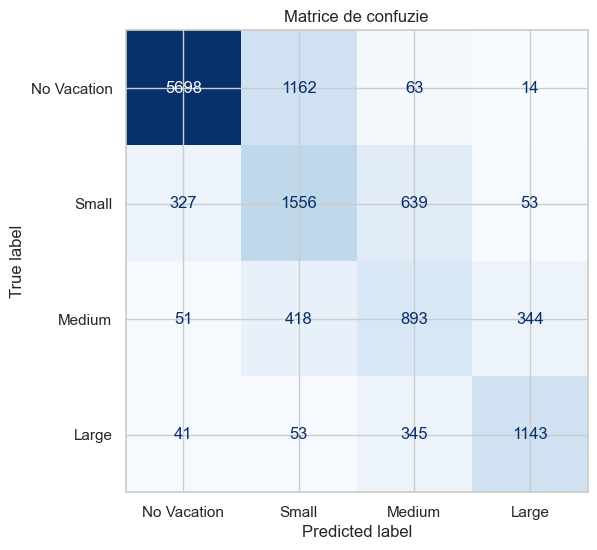


 Performanță pe setul de test
              precision    recall  f1-score   support

 No Vacation       0.93      0.81      0.86      8672
       Small       0.48      0.61      0.54      3219
      Medium       0.49      0.55      0.52      2132
       Large       0.76      0.74      0.75      1977

    accuracy                           0.73     16000
   macro avg       0.66      0.68      0.67     16000
weighted avg       0.76      0.73      0.74     16000



In [386]:
best_model = DecisionTreeClassifier(max_depth=BEST_DEPTH, min_samples_leaf=BEST_LEAF, class_weight='balanced')
best_model.fit(X_train_scaled, y_clf_train)
y_pred = best_model.predict(X_val_scaled)

print(classification_report(y_clf_val, y_pred, target_names=['No Vacation', 'Small', 'Medium', 'Large']))
# Matrice de confuzie pe validare
cm = confusion_matrix(y_clf_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Vacation', 'Small', 'Medium', 'Large'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matrice de confuzie')
plt.show()

# Evaluare și pe test
y_pred_test = best_model.predict(X_test_scaled)
print('\n Performanță pe setul de test')
print(classification_report(y_clf_test, y_pred_test, target_names=['No Vacation', 'Small', 'Medium', 'Large']))


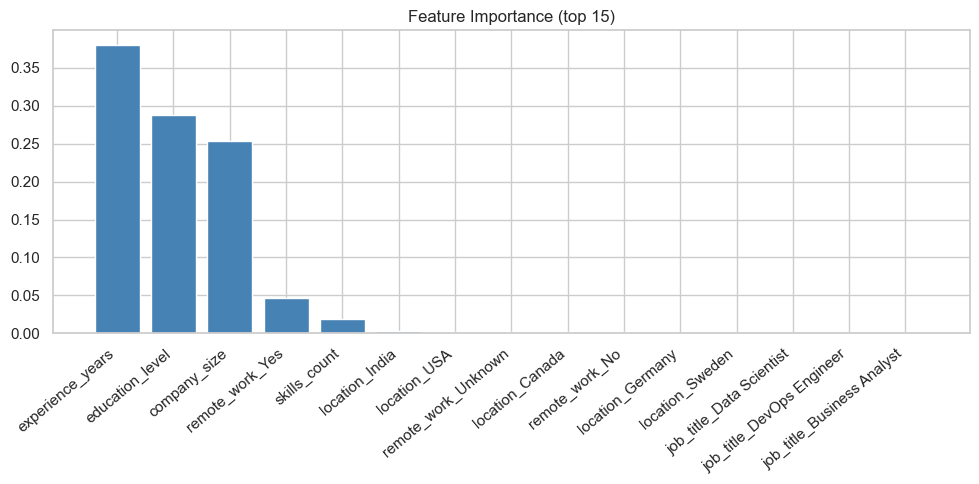

In [387]:
# Feature importance
feat_names = df_train.columns
importances = best_model.feature_importances_
top_n = 15

idx_sorted = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(10, 5))
plt.bar(range(top_n), importances[idx_sorted], color='steelblue', edgecolor='white')
plt.xticks(range(top_n), feat_names[idx_sorted], rotation=40, ha='right')
plt.title(f'Feature Importance (top {top_n})')
plt.tight_layout()
plt.show()


### 6.6. Regresie: Baseline (Linear Regression)

**Obiectiv:** Stabilim baseline pentru predicția salary cu regresia liniară simplă.


In [388]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_reg_train)

y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_val   = lr.predict(X_val_scaled)

def regression_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{label:30s}  MAE={mae:.0f}  RMSE={rmse:.0f}  R^2={r2:.4f}')
    return mae, rmse, r2

print('Baseline: LinearRegression')
mae_tr, rmse_tr, r2_tr = regression_metrics(y_reg_train, y_pred_lr_train, 'Train')
mae_vl, rmse_vl, r2_vl = regression_metrics(y_reg_val,   y_pred_lr_val,   'Validation')


Baseline: LinearRegression
Train                           MAE=6592  RMSE=8495  R^2=0.9483
Validation                      MAE=6660  RMSE=8596  R^2=0.9476


## 6.7. Regresie: Regularizare (Ridge & Lasso)

**Obiectiv:** Testăm Ridge (L2) și Lasso (L1) cu diferite valori alpha.
Graficul eroare train vs val ne arată dacă reducem overfitting-ul.


In [389]:
alphas = [0.01, 0.1, 1, 10, 100, 1000]

ridge_results = []
lasso_results = []

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_reg_train)
    ridge_results.append({
        'alpha': alpha,
        'train_rmse': np.sqrt(mean_squared_error(y_reg_train, ridge.predict(X_train_scaled))),
        'val_rmse':   np.sqrt(mean_squared_error(y_reg_val,   ridge.predict(X_val_scaled))),
        'val_r2':     r2_score(y_reg_val, ridge.predict(X_val_scaled)),
    })
    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_reg_train)
    lasso_results.append({
        'alpha': alpha,
        'train_rmse': np.sqrt(mean_squared_error(y_reg_train, lasso.predict(X_train_scaled))),
        'val_rmse':   np.sqrt(mean_squared_error(y_reg_val,   lasso.predict(X_val_scaled))),
        'val_r2':     r2_score(y_reg_val, lasso.predict(X_val_scaled)),
    })

df_ridge = pd.DataFrame(ridge_results).set_index('alpha')
df_lasso = pd.DataFrame(lasso_results).set_index('alpha')

print('Ridge — RMSE train vs val per alpha')
print(df_ridge.round({'train_rmse': 0, 'val_rmse': 0, 'val_r2': 4}).to_string())
print()
print('Lasso — RMSE train vs val per alpha')
print(df_lasso.round({'train_rmse': 0, 'val_rmse': 0, 'val_r2': 4}).to_string())

# Alegem cele mai bune valori alpha pe baza val_rmse
alpha_ridge_best = df_ridge['val_rmse'].idxmin()
alpha_lasso_best = df_lasso['val_rmse'].idxmin()
print(f'\nCel mai bun alpha Ridge: {alpha_ridge_best}')
print(f'Cel mai bun alpha Lasso: {alpha_lasso_best}')


Ridge — RMSE train vs val per alpha
         train_rmse  val_rmse  val_r2
alpha                                
0.01         8495.0    8596.0  0.9476
0.10         8495.0    8596.0  0.9476
1.00         8495.0    8596.0  0.9476
10.00        8495.0    8596.0  0.9476
100.00       8497.0    8599.0  0.9475
1000.00      8653.0    8766.0  0.9455

Lasso — RMSE train vs val per alpha
         train_rmse  val_rmse  val_r2
alpha                                
0.01         8495.0    8596.0  0.9476
0.10         8495.0    8596.0  0.9476
1.00         8495.0    8596.0  0.9476
10.00        8496.0    8596.0  0.9476
100.00       8574.0    8682.0  0.9465
1000.00     11299.0   11469.0  0.9067

Cel mai bun alpha Ridge: 0.01
Cel mai bun alpha Lasso: 1.0


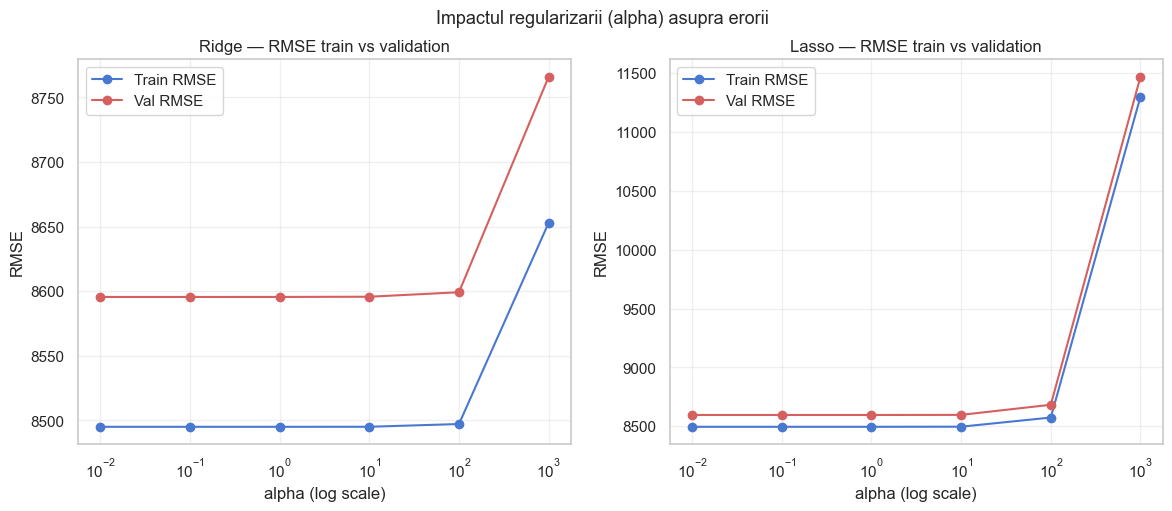

In [390]:
# Curbele de eroare train vs val — Ridge si Lasso
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Ridge
axes[0].semilogx(df_ridge.index, df_ridge['train_rmse'], 'b-o', label='Train RMSE')
axes[0].semilogx(df_ridge.index, df_ridge['val_rmse'],   'r-o', label='Val RMSE')
axes[0].set_title('Ridge — RMSE train vs validation')
axes[0].set_xlabel('alpha (log scale)')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Lasso
axes[1].semilogx(df_lasso.index, df_lasso['train_rmse'], 'b-o', label='Train RMSE')
axes[1].semilogx(df_lasso.index, df_lasso['val_rmse'],   'r-o', label='Val RMSE')
axes[1].set_title('Lasso — RMSE train vs validation')
axes[1].set_xlabel('alpha (log scale)')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Impactul regularizarii (alpha) asupra erorii', fontsize=13)
plt.show()

### 6.8. Regresie: Evaluare finală & Tabel comparativ

Comparăm toate modelele de regresie și alegem cel mai bun pe baza RMSE/R² pe validare.


In [391]:
# Folosim alfa-ele optime găsite anterior
models_reg = {
    'LinearRegression': LinearRegression(),
    f'Ridge(alpha={alpha_ridge_best})': Ridge(alpha=alpha_ridge_best),
    f'Lasso(alpha={alpha_lasso_best})': Lasso(alpha=alpha_lasso_best, max_iter=10000),
}

reg_comparison = []
for name, model in models_reg.items():
    model.fit(X_train_scaled, y_reg_train)
    y_p_val  = model.predict(X_val_scaled)
    y_p_test = model.predict(X_test_scaled)
    reg_comparison.append({
        'Model': name,
        'MAE val':  round(mean_absolute_error(y_reg_val, y_p_val), 0),
        'RMSE val': round(np.sqrt(mean_squared_error(y_reg_val, y_p_val)), 0),
        'R^2 val':  round(r2_score(y_reg_val, y_p_val), 4),
        'RMSE test': round(np.sqrt(mean_squared_error(y_reg_test, y_p_test)), 0),
        'R^2 test':  round(r2_score(y_reg_test, y_p_test), 4),
    })

df_reg_compare = pd.DataFrame(reg_comparison).set_index('Model')
display(df_reg_compare.style.highlight_max(subset=['R^2 val', 'R^2 test'], axis=0, props='font-weight: bold; background-color: #ffe9a8;')
        .highlight_min(subset=['MAE val', 'RMSE val', 'RMSE test'], axis=0,
         props='font-weight: bold; background-color: #ffe9a8;'))

# Alegere model cel mai bun pe baza RMSE val
best_reg_name = df_reg_compare['RMSE val'].idxmin()
print(f'\nCel mai bun model: {best_reg_name}')


,MAE val,RMSE val,R^2 val,RMSE test,R^2 test
Model,,,,,
LinearRegression,6660.000000,8596.000000,0.947600,8433.000000,0.948500
Ridge(alpha=0.01),6660.000000,8596.000000,0.947600,8433.000000,0.948500
Lasso(alpha=1.0),6660.000000,8596.000000,0.947600,8433.000000,0.948500



Cel mai bun model: LinearRegression


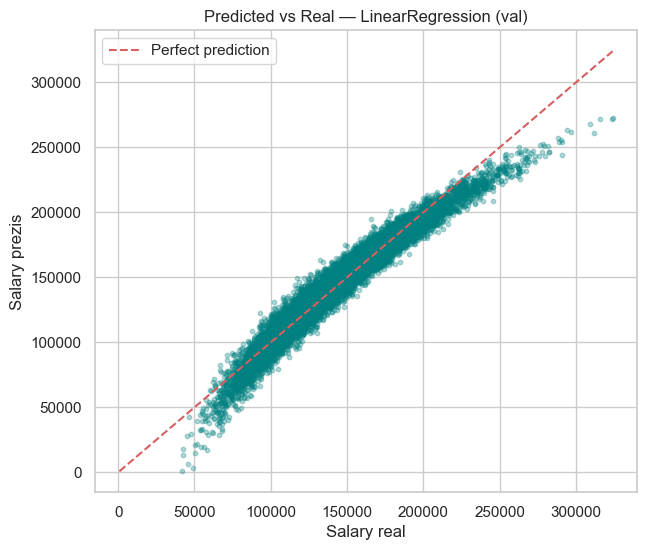

R^2 final pe validare: 0.9476
R^2 final pe test:     0.9485


In [392]:
best_reg = models_reg[best_reg_name]
y_pred_best_reg = best_reg.predict(X_val_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(y_reg_val, y_pred_best_reg, alpha=0.3, s=10, color='teal')
mn = min(y_reg_val.min(), y_pred_best_reg.min())
mx = max(y_reg_val.max(), y_pred_best_reg.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Salary real')
plt.ylabel('Salary prezis')
plt.title(f'Predicted vs Real — {best_reg_name} (val)')
plt.legend()
plt.show()

r2_final = r2_score(y_reg_val, y_pred_best_reg)
print(f'R^2 final pe validare: {r2_final:.4f}')

# Și pe test
y_pred_test_reg = best_reg.predict(X_test_scaled)
r2_test = r2_score(y_reg_test, y_pred_test_reg)
print(f'R^2 final pe test:     {r2_test:.4f}')
